Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data

In [2]:
df = pd.read_csv("data/ethiopia.csv")
df["Country"] = "Ethiopia"

Change Date format & Extract month

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

Cleaning (replacing -999 with nan and dropping duplicates)

In [4]:
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


the data has no duplicate values.

summary statistics

In [5]:
df.head(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


The data contains of daily measurements of temperature, precipitation, humidity, and wind from year 2015 to 2026.This output shows the central tendencies and quartiles of the data. it shows thta for column. The mean for example in column T2M, 16.07°C was the average temperature. the range for temperature shows that it ranges fron 10.03°C to 21.53°C across all days. the percipitation column shows that rainfall ranges from 0 mm which were dry days to 82.3 mm which was heavy rain.
the standard deviations shows moderate variability in all variables and we can also see that there were no missing values.

MIssing value

In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Percent": missing_percent
})

missing_report

,Missing Count,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


the output shows that there are no missing values so we can contine with the analysis and we dont need to do further process to fix this.

Handling outliers

In [8]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


Cap the outliers (it keeps all rows & it prevents extreme distortion by extreme values)

In [9]:
for col in cols:
    upper = df[col].mean() + 3*df[col].std()
    lower = df[col].mean() - 3*df[col].std()
    df[col] = np.clip(df[col], lower, upper)

export cleaned data

In [10]:
df.to_csv("data/ethiopia_clean.csv", index=False)

time series analysis

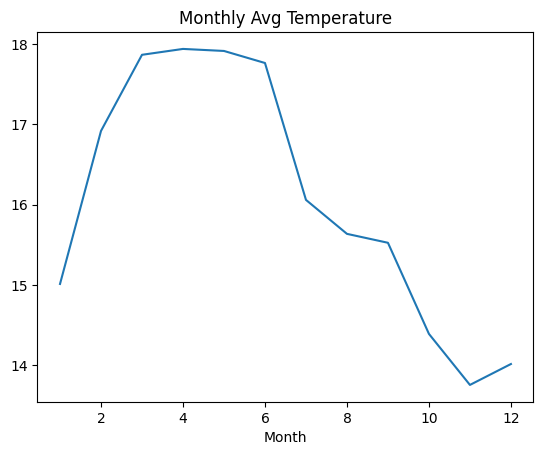

In [11]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Avg Temperature")
plt.show()

4th month had the highest average temperature while the 11th month had the lowest amount of average temperature over the years.

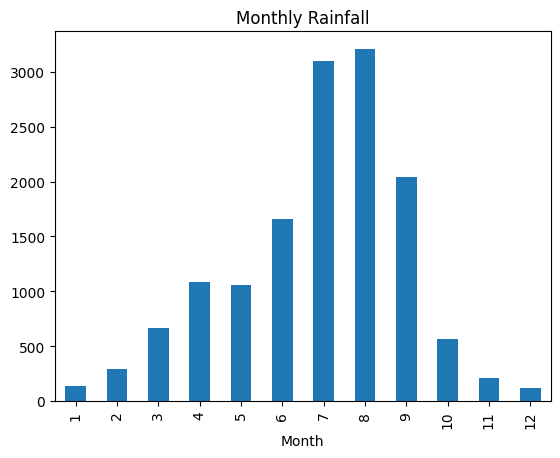

In [12]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

the bar chart shows that 8th, 7th, 9th, 6th and 5th months had the highest average rainfall respectively while the 12th month had the lowest amount of average rainfall over the years.

the line chart shows that the temperature consistently decreases over the months throughout the years. 

correlation analysis

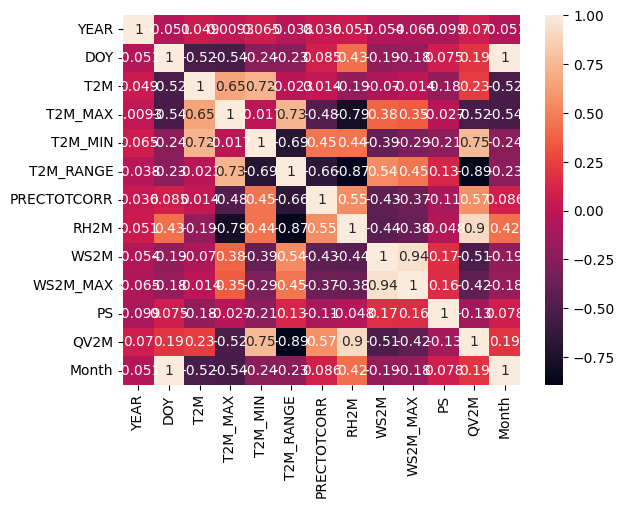

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

this correlation analysis shows that the daily range temperature and specific humididty are highly negatively correlated which means that when one increases the other decreases. 
the daily range temperature is also negatively correlated with the relative humidity. another strong correlation is between maximum daily temperature and relative humidity which are also negatively correlated. 

scatter plot

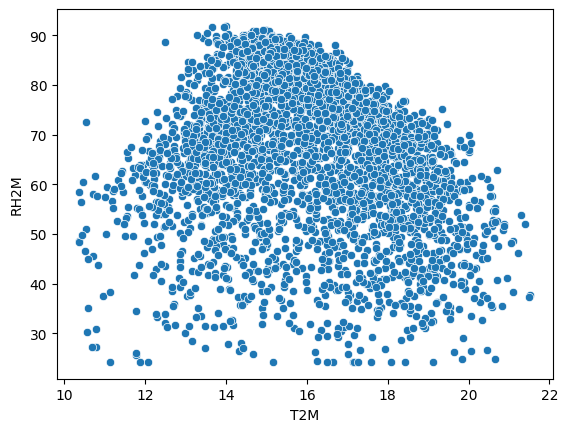

In [14]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

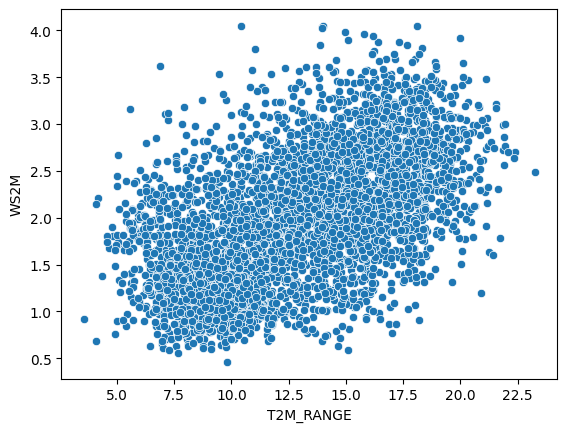

In [15]:
sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

histogram

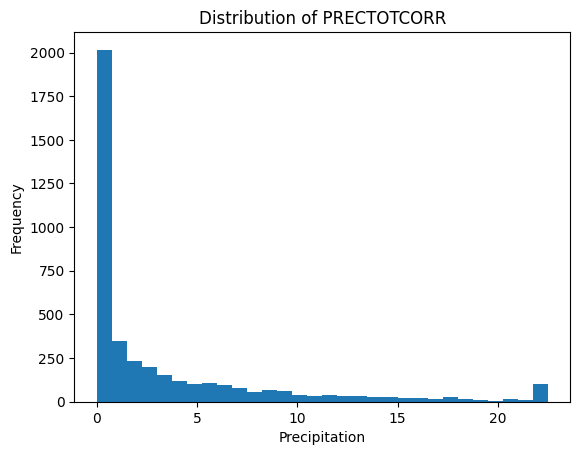

In [16]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.title("Distribution of PRECTOTCORR")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()

it is skewed to the right with most days experiencing low precipitation and a few extreme rainfall events. .so apply log scale to better visualize the distribution

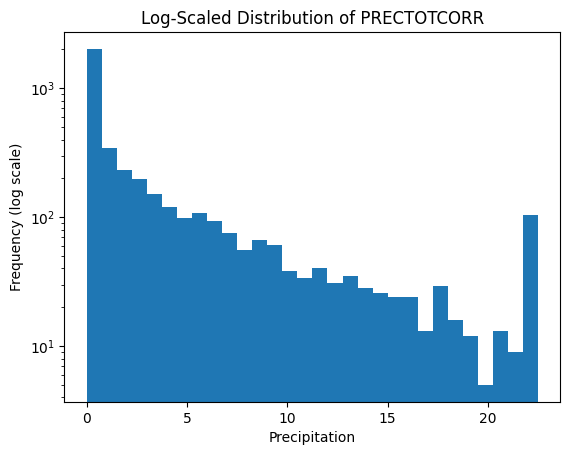

In [17]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.yscale("log")
plt.title("Log-Scaled Distribution of PRECTOTCORR")
plt.xlabel("Precipitation")
plt.ylabel("Frequency (log scale)")
plt.show()

bubble chart

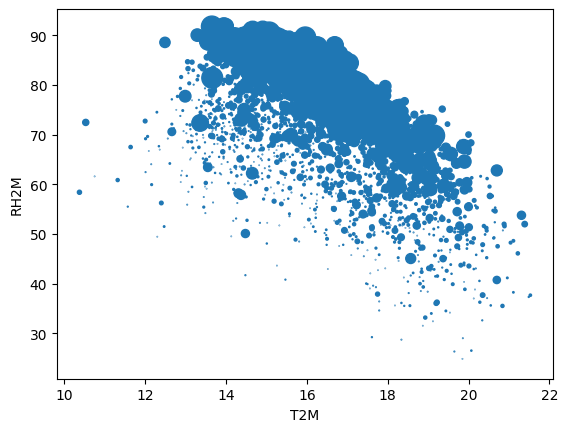

In [18]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()